## Dataset Preparation
Feature and Target Sepearation

In [1]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

words = open('../data/names.txt', 'r').read().splitlines()

In [2]:
chars = sorted(set(''.join(words)))

stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {s:i for i,s in stoi.items()}

# itos[1] = 'a'
# stoi['a'] = 1

In [10]:
CONTEXT_SIZE = 3

X = []
y = []
for w in words:
    # print(w)
    context = [0] * CONTEXT_SIZE
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        y.append(ix)

        context = context[1:] + [ix]
        # print(''.join(itos[i] for i in context), '--->', itos[ix])


# X is [x1, x2, x3, ... xN] 
X = torch.tensor(X)
y = torch.tensor(y)

In [11]:
DIM_SIZE = 2

# C is an embedded dimension
C = torch.randn((27, DIM_SIZE))

# OHE, but we do it algebraically (it's the same zero cancel out effect)
emb = C[X]

print(X.shape)
print(C.shape)
print(emb.shape)

torch.Size([228146, 3])
torch.Size([27, 2])
torch.Size([228146, 3, 2])


In [12]:
W1 = torch.randn((CONTEXT_SIZE * DIM_SIZE, 100))
B1 = torch.randn(100)

h = torch.tanh(emb.view(-1, CONTEXT_SIZE * DIM_SIZE) @ W1 + B1)
h.shape

torch.Size([228146, 100])

In [13]:
W2 = torch.randn((100, 27))
B2 = torch.randn(27)

logits = h @ W2 + B2
counts = logits.exp()
probs = counts/counts.sum(1, keepdims=True)


## Unified Version

In [79]:
g  = torch.Generator().manual_seed(2147483647)
C  = torch.randn((27, DIM_SIZE), generator=g) 
W1 = torch.randn((CONTEXT_SIZE * DIM_SIZE, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [78]:
import torch.nn.functional as F

epochs = 1000
batch  = 64
lr = 0.001


lre = torch.linspace(-3, 0, epochs)
lrs = 10**lre

lri = []
lossi = []

In [99]:
for i in range(epochs):
    # forward pass
    ix = torch.randint(0, X.shape[0], (batch,))

    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, CONTEXT_SIZE * DIM_SIZE) @ W1 + b1)
    logits = h @ W2 + b2

    loss = F.cross_entropy(logits, y[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = lrs[i]
    for p in parameters:
        p.data -= lr * p.grad

    lri.append(lre[i])
    lossi.append(loss.item())

    if i % 100 == 0:
        print(loss.item())

3.2638771533966064
3.0912301540374756
2.3799495697021484
2.9097471237182617
2.3394272327423096
2.2913341522216797
2.3242344856262207
2.407797336578369
2.3177380561828613
2.6810877323150635


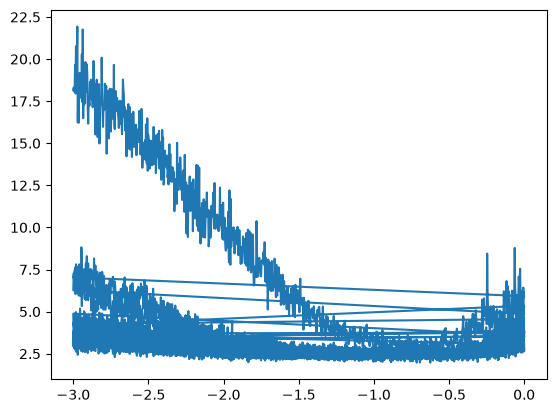

In [100]:
plt.plot(lri, lossi)

In [101]:
emb = C[X]
h = torch.tanh(emb.view(-1, CONTEXT_SIZE * DIM_SIZE) @ W1 + b1)
logits = h @ W2 + b2

loss = F.cross_entropy(logits, y)

loss.item()

2.846237897872925